<a href="https://colab.research.google.com/github/Ria-varsha/CN_LAB_2025-2026/blob/main/tourism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install geopandas shapely pyproj fiona

In [3]:
from google.colab import files
uploaded = files.upload()

Saving tourism_exact_190_raw.csv to tourism_exact_190_raw.csv


In [5]:
import pandas as pd
df = pd.read_csv("tourism_exact_190_raw.csv")
df.head()

,Continent,Country,City,Arrivals_2019,Arrivals_2022,Arrivals_2023,ISO
0,Europe,France,France_City13,61.3,62.7,74.5,FRA
1,Europe,Spain,Spain_City8,45.2,41.7,43.5,SPA
2,Europe,Italy,Italy_City7,10.4,7.7,10.3,ITA
3,Europe,Germany,Germany_City8,55.2,48.8,69.3,GER
4,Europe,UK,UK_City14,37.1,34.3,34.2,UK


In [6]:
print("Total rows:", len(df))
df.info()

Total rows: 190
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Continent      190 non-null    object 
 1   Country        190 non-null    object 
 2   City           186 non-null    object 
 3   Arrivals_2019  190 non-null    float64
 4   Arrivals_2022  190 non-null    float64
 5   Arrivals_2023  190 non-null    float64
 6   ISO            190 non-null    object 
dtypes: float64(3), object(4)
memory usage: 10.5+ KB


In [7]:
df["Is_Continent"] = df["Country"].str.upper().str.contains("TOTAL")
df[df["Is_Continent"]]

,Continent,Country,City,Arrivals_2019,Arrivals_2022,Arrivals_2023,ISO,Is_Continent
186,Europe,EUROPE TOTAL,NaN,800.0,700.0,820.0,EUR,True
187,Asia,ASIA TOTAL,NaN,600.0,500.0,620.0,ASI,True
188,Africa,AFRICA TOTAL,NaN,300.0,280.0,310.0,AFR,True
189,Americas,AMERICAS TOTAL,NaN,900.0,800.0,950.0,AME,True


In [8]:
df_clean = df[~df["Is_Continent"]].copy()
print("Rows after cleaning:", len(df_clean))
df_clean.head()

Rows after cleaning: 186


,Continent,Country,City,Arrivals_2019,Arrivals_2022,Arrivals_2023,ISO,Is_Continent
0,Europe,France,France_City13,61.3,62.7,74.5,FRA,False
1,Europe,Spain,Spain_City8,45.2,41.7,43.5,SPA,False
2,Europe,Italy,Italy_City7,10.4,7.7,10.3,ITA,False
3,Europe,Germany,Germany_City8,55.2,48.8,69.3,GER,False
4,Europe,UK,UK_City14,37.1,34.3,34.2,UK,False


In [9]:
print("Before cleaning:", len(df))
print("After cleaning:", len(df_clean))

Before cleaning: 190
After cleaning: 186


In [10]:
import numpy as np
df_clean["pct_growth"] = (
    (df_clean["Arrivals_2023"] - df_clean["Arrivals_2019"]) /
    df_clean["Arrivals_2019"].replace(0, np.nan)
) * 100
df_clean["pct_growth"] = df_clean["pct_growth"].clip(-100, 100)
df_clean[["Country", "pct_growth"]].head()

,Country,pct_growth
0,France,21.533442
1,Spain,-3.761062
2,Italy,-0.961538
3,Germany,25.543478
4,UK,-7.816712


In [11]:
df_clean.isnull().sum()

,0
Continent,0
Country,0
City,0
Arrivals_2019,0
Arrivals_2022,0
Arrivals_2023,0
ISO,0
Is_Continent,0
pct_growth,0


In [12]:
df_clean.describe()

,Arrivals_2019,Arrivals_2022,Arrivals_2023,pct_growth
count,186.000000,186.00000,186.000000,186.000000
mean,53.730645,46.15000,54.836022,1.157308
std,26.835317,24.64092,30.143694,17.994996
min,5.900000,5.60000,5.600000,-29.515419
25%,31.650000,25.52500,31.325000,-14.908700
50%,54.650000,45.35000,51.600000,1.938161
75%,74.325000,63.07500,77.725000,16.889023
max,99.200000,106.90000,124.300000,29.701493


In [14]:
import geopandas as gpd
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [16]:
world_data = world.merge(
    df_clean,
    left_on="ISO_A3",
    right_on="ISO",
    how="left"
)

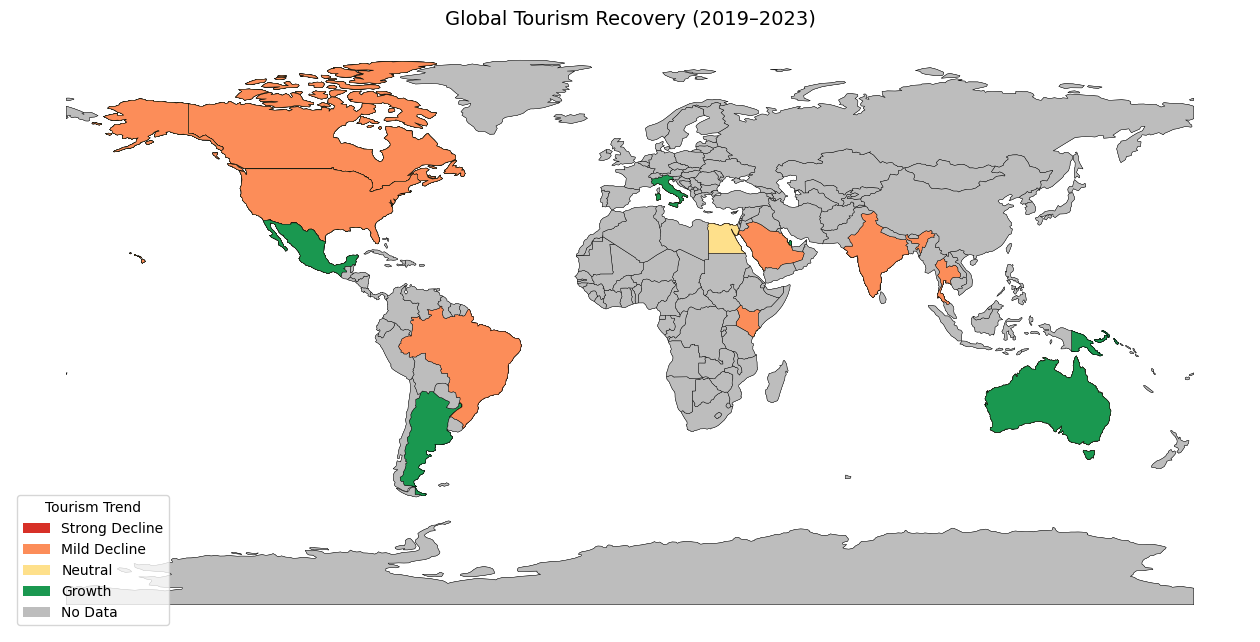

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world_data = world.merge(
    df_clean,
    left_on="ISO_A3",
    right_on="ISO",
    how="left"
)

world_data["pct_growth"] = world_data["pct_growth"].round(1)

bins = [-100, -10, 0, 10, 100]
colors = ["#d73027", "#fc8d59", "#fee08b", "#1a9850"]
cmap = mcolors.ListedColormap(colors)

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

world.plot(ax=ax, color="#d9d9d9", edgecolor="black", linewidth=0.3)

world_data.plot(
    column="pct_growth",
    cmap=cmap,
    scheme="user_defined",
    classification_kwds={"bins": bins},
    linewidth=0.3,
    edgecolor="black",
    ax=ax,
    missing_kwds={"color": "#bdbdbd"}
)

legend_elements = [
    Patch(facecolor="#d73027", label="Strong Decline"),
    Patch(facecolor="#fc8d59", label="Mild Decline"),
    Patch(facecolor="#fee08b", label="Neutral"),
    Patch(facecolor="#1a9850", label="Growth"),
    Patch(facecolor="#bdbdbd", label="No Data")
]

ax.legend(handles=legend_elements, title="Tourism Trend", loc="lower left")

plt.title("Global Tourism Recovery (2019–2023)", fontsize=14)
plt.axis("off")

plt.show()